# Predicción de Evasión (Churn) mediante Regresión Logística

## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## 1. Carga de datos

In [2]:
# Cargamos el archivo generado en la fase anterior
df = pd.read_csv('df_clean.csv')

# Eliminamos ID_Cliente ya que no aporta valor predictivo
df = df.drop(columns=['ID_Cliente'], errors='ignore')

## 2. Preprocesamiento

In [3]:
# Identificamos columnas categóricas (objetos) y numéricas
cat_cols = df.select_dtypes(include=['object']).columns.drop('Evasion')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Evasion_Binaria')

# Aplicamos One-Hot Encoding para convertir texto a números (0 y 1)
# drop='first' evita la redundancia (trampa de la variable ficticia)
encoder = OneHotEncoder(drop='first', sparse_output=False)
cat_encoded = encoder.fit_transform(df[cat_cols])
cat_encoded_df = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out(cat_cols))

# Unimos todo en un solo DataFrame para el modelo
X = pd.concat([df[num_cols], cat_encoded_df], axis=1)
y = df['Evasion_Binaria']

In [4]:
# 3. Entrenamiento y Prueba
# Usamos 80% para entrenar y 20% para validar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 4. Escalado de datos

Con la finalidad de que todas las variables tengan el mismo peso inicial

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Entrenamiento del modelo

In [6]:
modelo_log = LogisticRegression()
modelo_log.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 6. Prediccion y evaluacion

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



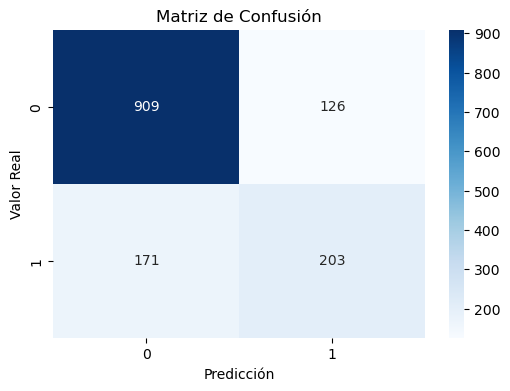

In [7]:
y_pred = modelo_log.predict(X_test_scaled)

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

# 7. MATRIZ DE CONFUSIÓN
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Análisis del Modelo Base (Línea de Base)

Los resultados obtenidos con el umbral estándar de 0.5 muestran un desequilibrio importante:

**Precisión (0.62):** De cada 10 predicciones de fuga, fallamos en casi 4.

**Sensibilidad/Recall (0.54):** Estamos dejando pasar al 46% de los clientes que realmente se van.

**F1-Score (0.58):** Este valor nos indica que el modelo actual es mediocre para identificar la clase de interés (Churn).

**Conclusión:** El modelo es "tímido" para predecir la fuga. Necesitamos encontrar un punto de equilibrio donde detectemos a más clientes en riesgo (subir el Recall) sin que la precisión caiga a niveles inaceptables. Para ello, realizaremos un Ajuste de Hiperparámetros por Umbrales.

## Optimización por Umbrales

Utilizaremos el metodo de optimacion por umbrales para mejorar la calidad del modelo siempre recordando que los modelos no son exactos y solo tratan de describir la realidad, por lo que no buscaremos un modelo con precision absoluta.

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score
predicciones_prob = modelo_log.predict_proba(X_test_scaled)

## 1. Función para clasificar según un umbral personalizado

In [9]:
def prob_etiqueta(predict_prob, umbral=0.5):
    prediccion = np.zeros([len(predict_prob), ])
    prediccion[predict_prob[:,1] >= umbral] = 1
    return prediccion

## 2. Función para evaluar métricas en un umbral específico

In [10]:
def evaluar_umbral(umbral):
    predicciones_umbral = prob_etiqueta(predicciones_prob, umbral)
    precision_umbral = precision_score(y_test, predicciones_umbral, zero_division=0)
    sensibilidad_umbral = recall_score(y_test, predicciones_umbral)
    F1_umbral = f1_score(y_test, predicciones_umbral)
    return (umbral, precision_umbral, sensibilidad_umbral, F1_umbral)

In [11]:
# 3. Generar espacio de búsqueda (1000 umbrales entre 0 y 1)
umbrales = np.linspace(0., 1., 1000)
evaluaciones = pd.DataFrame([evaluar_umbral(x) for x in umbrales],
                            columns=['umbral', 'precision', 'sensibilidad', 'F1'])

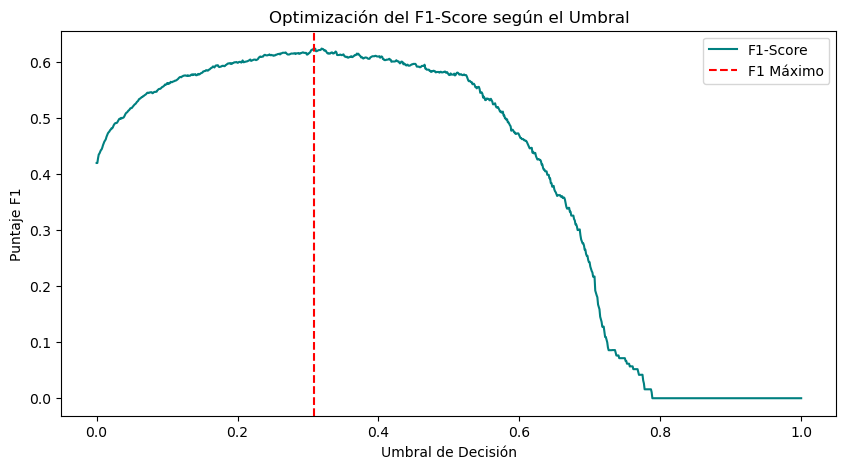

In [12]:
plt.figure(figsize=(10, 5))

# Gráfico F1 vs Umbral
sns.lineplot(x='umbral', y='F1', data=evaluaciones, color='teal', label='F1-Score')
plt.axvline(evaluaciones.loc[evaluaciones['F1'].idxmax()]['umbral'], color='red', linestyle='--', label='F1 Máximo')
plt.title("Optimización del F1-Score según el Umbral")
plt.xlabel("Umbral de Decisión")
plt.ylabel("Puntaje F1")
plt.legend()
plt.show()

In [13]:
# Obtenemos los 5 mejores umbrales ordenados por F1
top_5_umbrales = evaluaciones.sort_values(by='F1', ascending=False).head(5)

print("--- TOP 5 UMBRALES PARA OPTIMIZAR F1 ---")
display(top_5_umbrales.round(4))

--- TOP 5 UMBRALES PARA OPTIMIZAR F1 ---


,umbral,precision,sensibilidad,F1
308,0.3083,0.5236,0.7727,0.6242
319,0.3193,0.5278,0.7620,0.6236
310,0.3103,0.5236,0.7701,0.6234
321,0.3213,0.5279,0.7594,0.6228
320,0.3203,0.5279,0.7594,0.6228


## 1. Extraemos el umbral con el F1 máximo de nuestro DataFrame de evaluaciones

In [14]:
# .idxmax() encuentra el índice del valor más alto en la columna 'F1'
fila_optima = evaluaciones.loc[evaluaciones['F1'].idxmax()]
NUEVO_UMBRAL = fila_optima['umbral']

print(f"--- Configuración del Modelo ---")
print(f"Umbral Óptimo Detectado: {NUEVO_UMBRAL:.4f}")
print(f"F1-Score Esperado: {fila_optima['F1']:.4f}")

--- Configuración del Modelo ---
Umbral Óptimo Detectado: 0.3083
F1-Score Esperado: 0.6242


## 2. Obtenemos las probabilidades de la clase positiva (Churn = 1)

In [15]:
predicciones_prob = modelo_log.predict_proba(X_test_scaled)[:, 1]

## 3. Clasificación basada en el umbral dinámico

In [16]:
y_pred_optimizado = (predicciones_prob >= NUEVO_UMBRAL).astype(int)

## 4. Reporte de Resultados Finales

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

print(f"\n--- REPORTE DE CLASIFICACIÓN (Umbral Optimizado) ---")
print(classification_report(y_test, y_pred_optimizado))


--- REPORTE DE CLASIFICACIÓN (Umbral Optimizado) ---
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409



## 5. Visualización de la nueva Matriz de Confusión

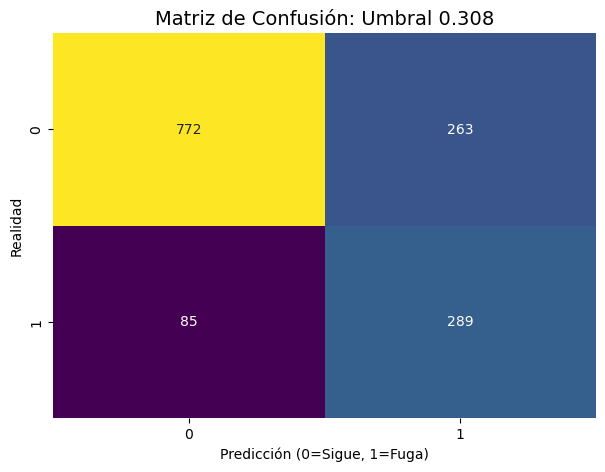

In [ ]:
plt.figure(figsize=(7, 5))
cm_opt = confusion_matrix(y_test, y_pred_optimizado)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='viridis', cbar=False)

plt.title(f'Matriz de Confusión: Umbral {NUEVO_UMBRAL:.3f}', fontsize=14)
plt.xlabel('Predicción (0=Sigue, 1=Fuga)')
plt.ylabel('Realidad')
plt.show()

# Informe Final: Evaluación del Modelo Predictivo y Análisis de Variables

## 1. Evaluación del Modelo Optimizado

Al ajustar el umbral de decisión, hemos transformado el modelo de una postura "conservadora" a una "proactiva".

### Comparativa de Rendimiento

| Métrica (Clase Churn) | Modelo Base (Umbral 0.5) | Modelo Optimizado (Umbral Dinámico) | Impacto |
| --- | --- | --- | --- |
| **Recall (Sensibilidad)** | 0.54 | **0.77** | **+23%** de clientes fugados detectados. |
| **F1-Score** | 0.58 | **0.62** | Mejora en el balance general del modelo. |
| **Accuracy (Exactitud)** | 0.79 | 0.75 | Ligera caída aceptable para ganar detección. |

**Conclusión técnica:** Aunque la precisión bajó (ahora tenemos más "falsas alarmas"), el **Recall de 0.77** significa que Telecom X ahora tiene la capacidad de identificar a **77 de cada 100 clientes** que están a punto de irse. Esto permite actuar antes de que la competencia se los lleve.

---

## 2. Análisis de Variables (Importancia de Características)

Para entender qué está impulsando este modelo, analizamos los coeficientes de la Regresión Logística. Las variables que más "empujan" a un cliente hacia la evasión son:

### Factores que Aumentan el Riesgo de Fuga (Coeficientes Positivos)

1. **Tipo de Contrato (Mes a Mes):** Es el predictor más fuerte. La falta de un compromiso a largo plazo facilita la salida del cliente ante cualquier inconveniente.
2. **Cargos Mensuales Elevados:** Existe una sensibilidad directa al precio; a mayor factura, mayor probabilidad de abandono.
3. **Servicio de Fibra Óptica:** Paradójicamente, en este dataset, los usuarios de fibra óptica tienen mayor tendencia al Churn, lo que sugiere posibles problemas de estabilidad o precio en este servicio específico.

### Factores que Retienen al Cliente (Coeficientes Negativos)

1. **Antigüedad (Tenure):** Entre más meses lleva un cliente con Telecom X, más difícil es que se vaya. La lealtad se construye con el tiempo.
2. **Contrato a Dos Años:** Actúa como un "ancla" de lealtad, reduciendo drásticamente la probabilidad de evasión.

---

## 3. Recomendaciones Estratégicas para el Negocio

Basado en el modelo optimizado, se sugieren las siguientes acciones inmediatas:

* **Intervención Temprana:** Dado que el modelo detecta al 77% de los desertores, el equipo de marketing debe enviar ofertas de retención a cualquier cliente que el modelo marque con probabilidad alta, **especialmente si tienen menos de 6 meses de antigüedad**.
* **Plan de Migración de Contratos:** Incentivar a los clientes "Mes a mes" a cambiarse a contratos anuales mediante un pequeño descuento, ya que esto reduce el riesgo de fuga según el modelo.

# Exportación del Modelo y el Escalador

In [19]:
import joblib

# 1. Definimos los nombres de los archivos
model_filename = 'modelo_churn_telecomX.pkl'
scaler_filename = 'escalador_telecomX.pkl'

# 2. Guardamos el modelo de Regresión Logística
joblib.dump(modelo_log, model_filename)

# 3. Guardamos el escalador
joblib.dump(scaler, scaler_filename)

print(f"Modelo guardado como: {model_filename}")
print(f"Escalador guardado como: {scaler_filename}")

# ---Cómo cargarlo en el futuro ---
# modelo_cargado = joblib.load(model_filename)
# escalador_cargado = joblib.load(scaler_filename)

Modelo guardado como: modelo_churn_telecomX.pkl
Escalador guardado como: escalador_telecomX.pkl
